In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, classification_report, accuracy_score, roc_auc_score

In [93]:
df_merged = pd.read_csv('merged_flight_weather_data.csv')

In [94]:
if 'DepDel15' in df_merged.columns:
    y = df_merged['DepDel15'].astype(int)
else:
    y = (df_merged['DepDelayMinutes'] >= 15).astype(int)

In [95]:
features = ['Month', 'DayOfWeek', 'CRSDepTime', 'DEP_HOUR']
weather_cols = [col for col in df_merged.columns if col not in features and col not in [
    'FlightDate', 'Origin', 'Dest', 'Operating_Airline', 'Airline',
    'DepDelay', 'DepDelayMinutes', 'DepDel15', 'Is_Delayed'
] and df_merged[col].dtype in ['float64', 'int64']]

features.extend(weather_cols)
X = df_merged[features]


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

In [97]:
print(" تدريب النموذج (Random Forest) ")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=16,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

 تدريب النموذج (Random Forest) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [98]:
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [99]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

In [100]:
custom_threshold = 0.48
y_pred_final = (y_pred_proba >= best_threshold).astype(int)

In [101]:

print(f"أفضل عتبة تنبؤ تم حسابها (Best Threshold): {best_threshold:.3f}")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("=== تقرير التصنيف التفصيلي ===")
print(classification_report(y_test, y_pred_final))

أفضل عتبة تنبؤ تم حسابها (Best Threshold): 0.455
Accuracy Score: 0.5390
ROC AUC Score: 0.6108
=== تقرير التصنيف التفصيلي ===
              precision    recall  f1-score   support

           0       0.85      0.51      0.64     84715
           1       0.24      0.64      0.35     20664

    accuracy                           0.54    105379
   macro avg       0.55      0.58      0.50    105379
weighted avg       0.73      0.54      0.59    105379



In [102]:
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n=== ترتيب الميزات الأكثر تأثيراً ===")
print(feature_df)


=== ترتيب الميزات الأكثر تأثيراً ===
                       Feature  Importance
6                     Distance    0.510999
2                   CRSDepTime    0.243935
1                    DayOfWeek    0.132985
20      HOURLYWindDirectionCos    0.017366
10          HOURLYDRYBULBTEMPF    0.016769
13      HOURLYRelativeHumidity    0.016366
11          HOURLYWETBULBTEMPF    0.012089
3                     DEP_HOUR    0.008437
12         HOURLYDewPointTempF    0.007797
8                 WEATHER_HOUR    0.007306
9             HOURLYVISIBILITY    0.005745
14             HOURLYWindSpeed    0.004082
15       HOURLYStationPressure    0.002713
18      HOURLYAltimeterSetting    0.002708
21  HOURLYPressureTendencyIncr    0.002593
22  HOURLYPressureTendencyDecr    0.002399
16      HOURLYSeaLevelPressure    0.002296
23  HOURLYPressureTendencyCons    0.001973
19      HOURLYWindDirectionSin    0.000984
17                HOURLYPrecip    0.000459
7                WEATHER_MONTH    0.000000
5               

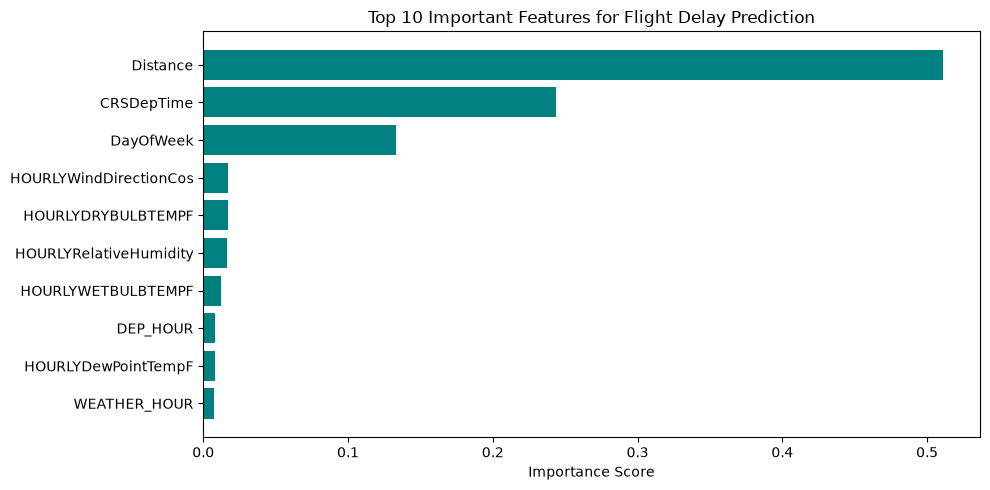

In [103]:
plt.figure(figsize=(10, 5))
plt.barh(feature_df['Feature'][:10][::-1], feature_df['Importance'][:10][::-1], color='teal')
plt.xlabel('Importance Score')
plt.title('Top 10 Important Features for Flight Delay Prediction')
plt.tight_layout()
plt.show()

In [104]:
import joblib

In [105]:
joblib.dump(rf_model, 'flight_delay_model.pkl')
print("تم حفظ النموذج بنجاح في ملف flight_delay_model.pkl")

تم حفظ النموذج بنجاح في ملف flight_delay_model.pkl
